In [1]:
from google.colab import files
uploaded = files.upload()

Saving Pharma_Industry.csv to Pharma_Industry.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [4]:
df = pd.read_csv("Pharma_Industry.csv")

df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [6]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [7]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


## Exploratory Data Analysis

EDA helps understand feature distributions, missing values, and relationships in the dataset.

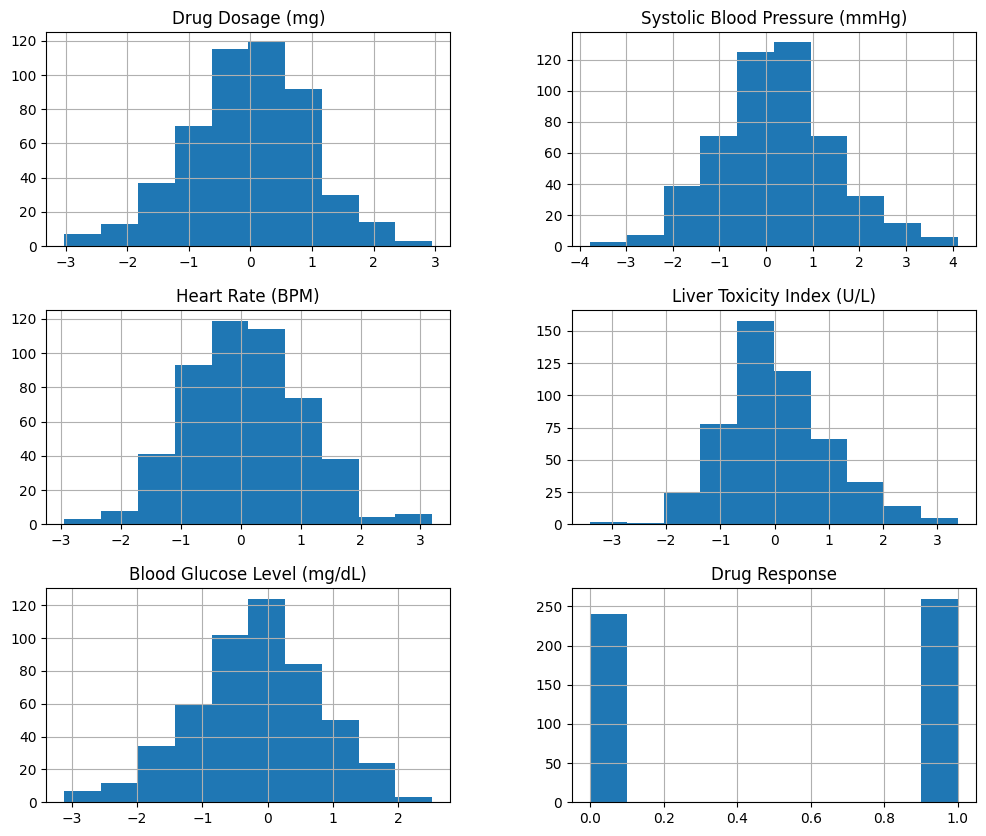

In [8]:
df.hist(figsize=(12,10))

plt.show()

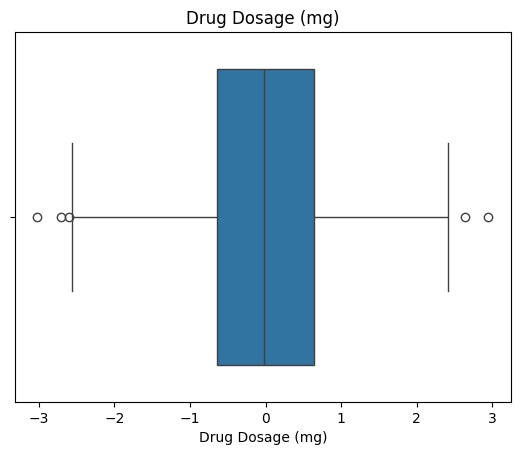

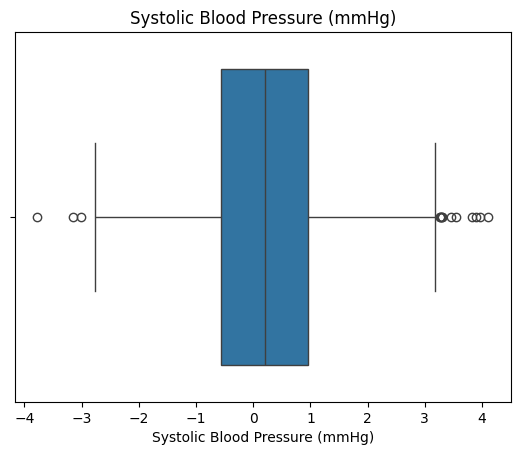

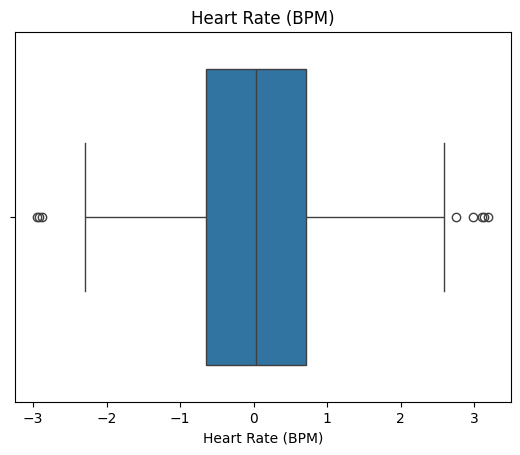

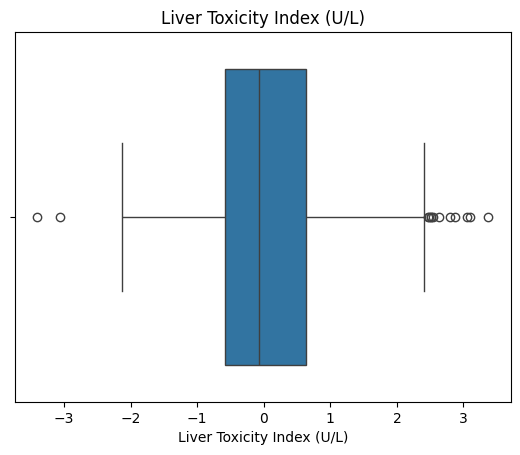

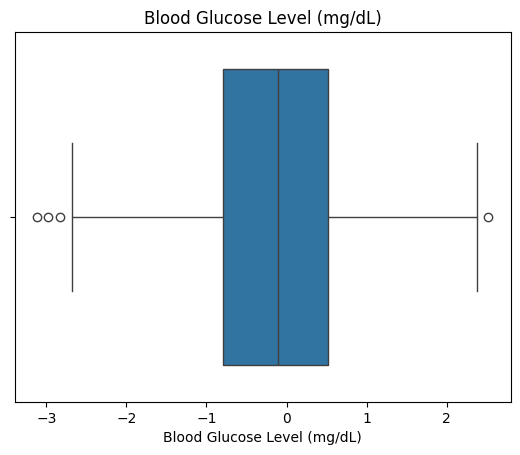

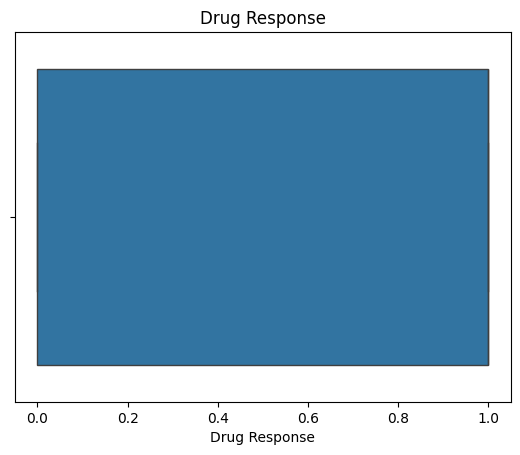

In [9]:
for col in df.select_dtypes(include=['int64','float64']).columns:

    plt.figure()

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

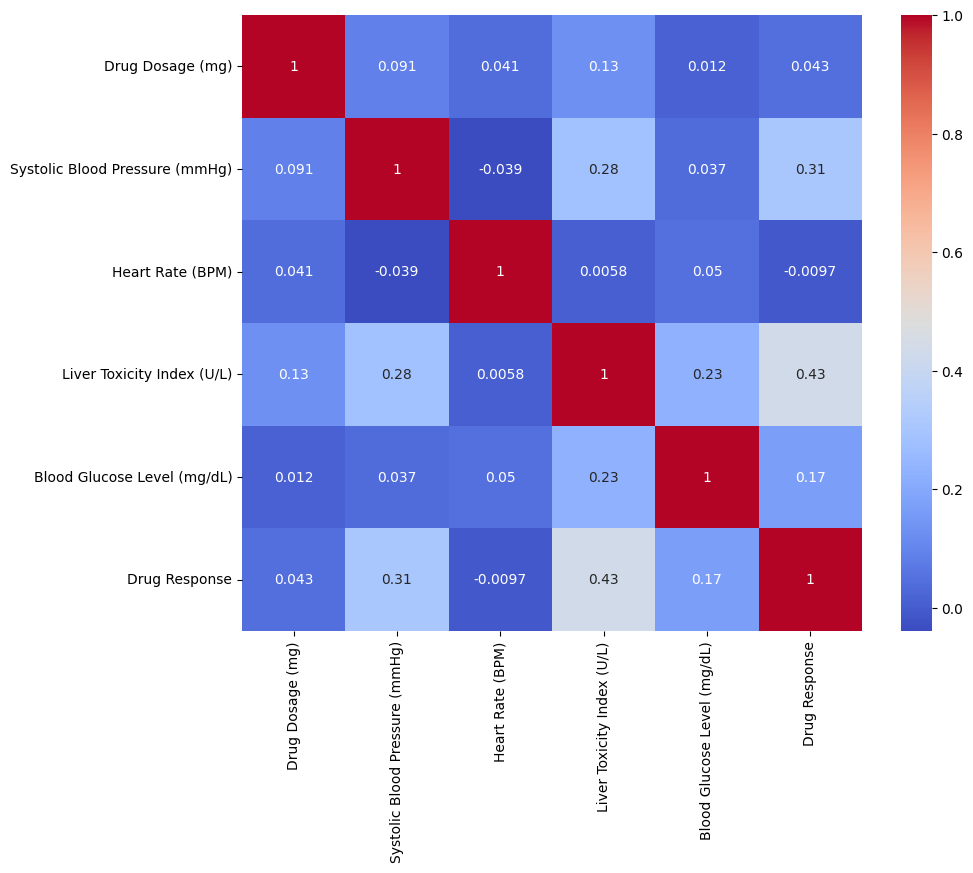

In [10]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.show()

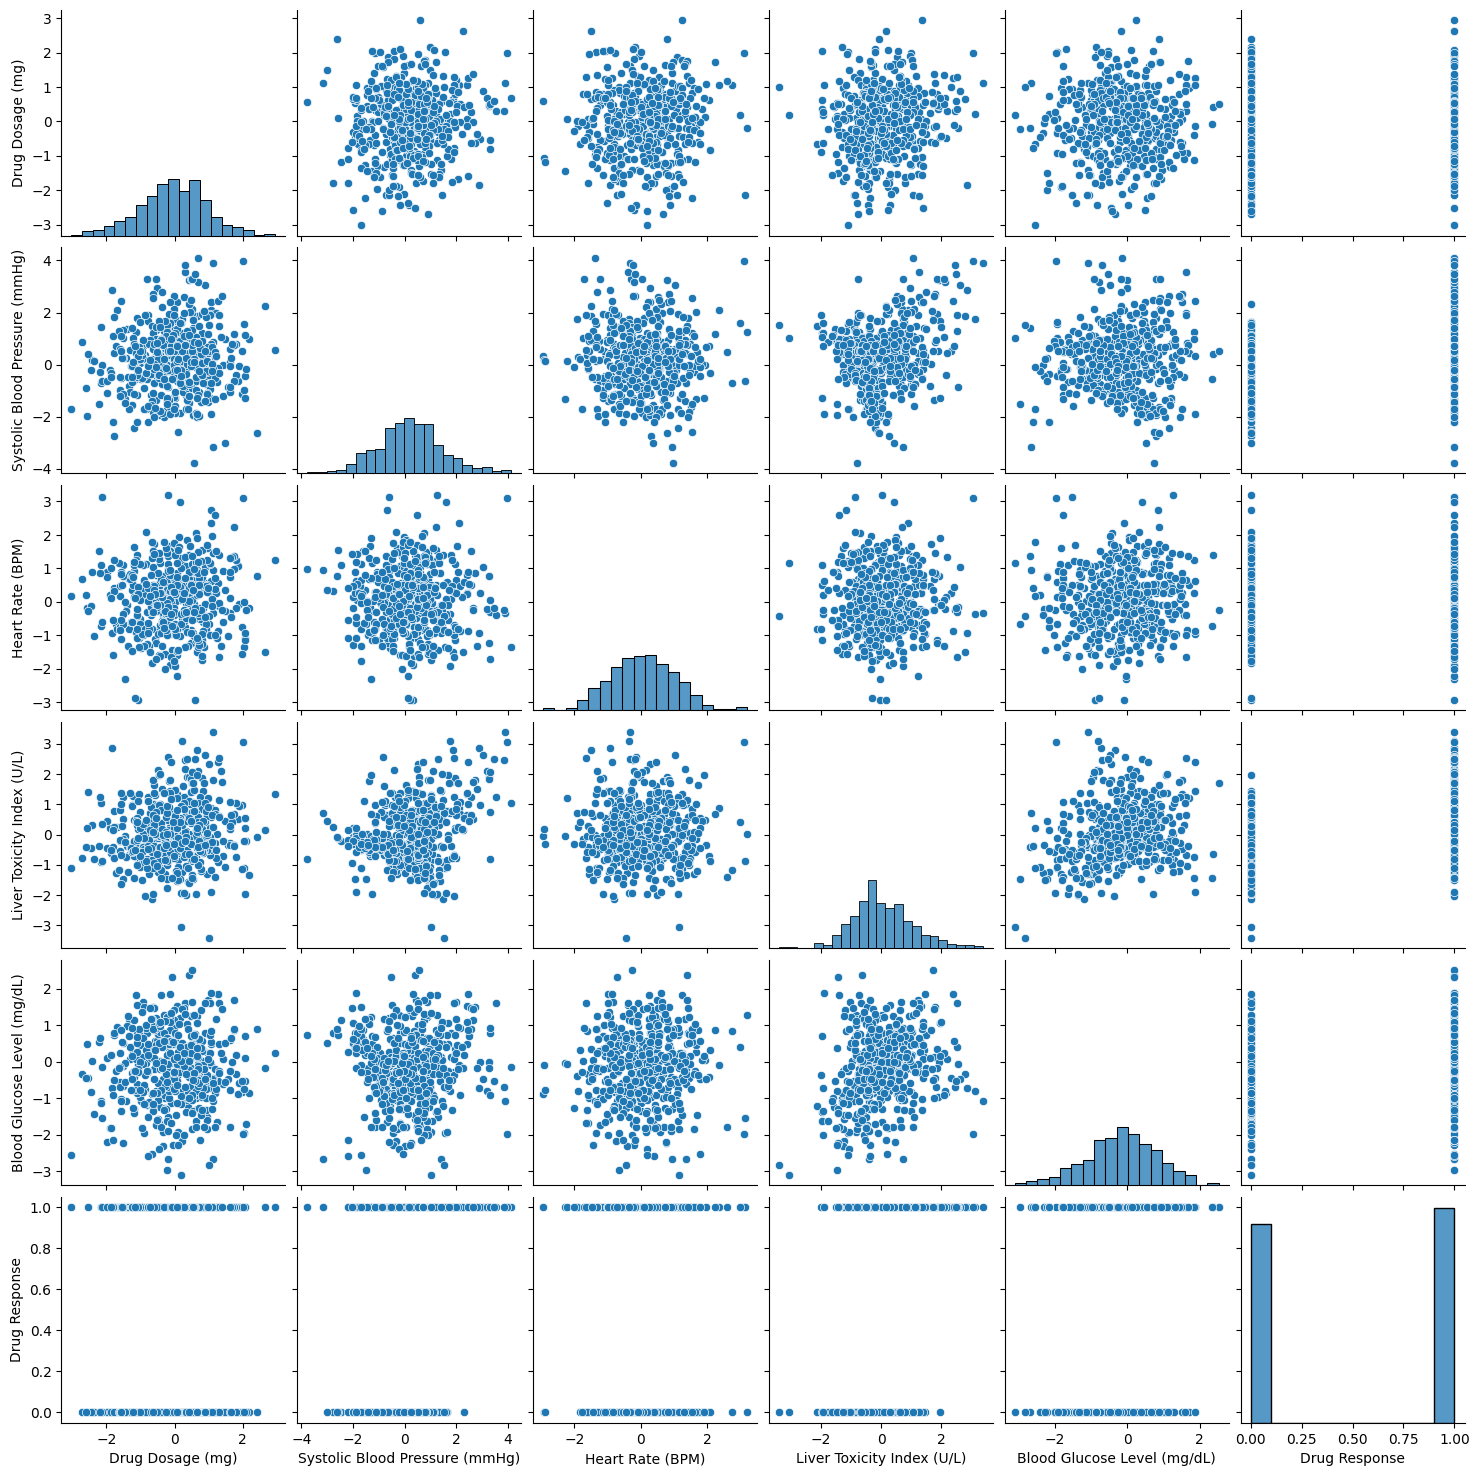

In [11]:
sns.pairplot(df)

plt.show()

## Visualization Insights

Visualizations help identify outliers, distributions, and relationships between variables.

In [12]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [13]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:

    df[col] = le.fit_transform(df[col])

## Encoding

Categorical variables were converted into numerical form using Label Encoding.

In [14]:
print(df.columns)

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')


In [16]:
X = df.drop('Drug Response', axis=1)

y = df['Drug Response']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(

    X, y,

    test_size=0.2,

    random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Feature Scaling

Standard Scaling improves SVM performance by normalizing feature ranges.

In [19]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [20]:
y_pred = svm_model.predict(X_test)

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.78


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



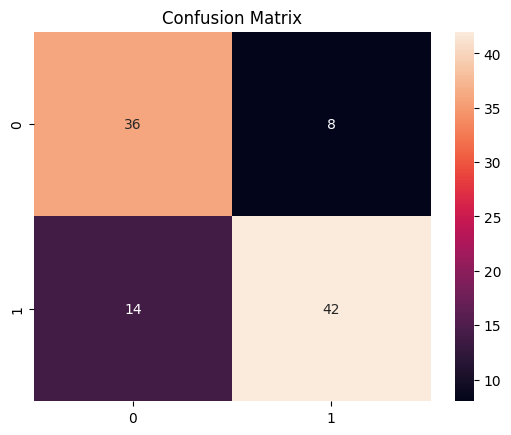

In [23]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

## Model Evaluation

Accuracy, precision, recall, and F1-score were used to evaluate the SVM classifier.

In [24]:
svm_linear = SVC(kernel='linear')

svm_linear.fit(X_train, y_train)

print("Linear Accuracy:",
      accuracy_score(y_test,
      svm_linear.predict(X_test)))

Linear Accuracy: 0.78


In [25]:
svm_poly = SVC(kernel='poly')

svm_poly.fit(X_train, y_train)

print("Polynomial Accuracy:",
      accuracy_score(y_test,
      svm_poly.predict(X_test)))

Polynomial Accuracy: 0.71


In [26]:
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train, y_train)

print("RBF Accuracy:",
      accuracy_score(y_test,
      svm_rbf.predict(X_test)))

RBF Accuracy: 0.84


## Kernel Comparison

Different kernels produce different decision boundaries.

- Linear kernel works well for linearly separable data.
- Polynomial kernel captures complex relationships.
- RBF kernel handles nonlinear patterns effectively.

In [27]:
svm_tuned = SVC(kernel='rbf', C=10, gamma=0.1)

svm_tuned.fit(X_train, y_train)

y_pred_tuned = svm_tuned.predict(X_test)

print("Tuned Accuracy:",
      accuracy_score(y_test, y_pred_tuned))

Tuned Accuracy: 0.84


## Parameter Tuning

Hyperparameters such as C and gamma were adjusted to improve model performance.

## Conclusion

The SVM classifier was successfully implemented and evaluated.

EDA and preprocessing improved data quality.
Different kernels were compared to analyze performance.

SVM performed effectively for classification tasks in the pharmaceutical dataset.

INTERVIEW QUESTIONS
 SVM Strengths
### Strengths of SVM
- Effective in high-dimensional spaces
- Works well with nonlinear data
- Robust against overfitting


### Weaknesses of SVM
- Slower for large datasets
- Difficult to interpret
- Sensitive to parameter tuning